# Сравнение пользовательской активности в мобильном приложении для чтения книг между Москвой и Санкт-Петербургом.

- Автор: Стукалов Артем Витальевич
- Дата: 06.03.2026

## Цели и задачи проекта

### Цель проекта
Провести комплексный статистический анализ времени за чтением и прослушиванием книг в приложении для групп пользователей из Москвы и Санкт-Петербурга, включая одностороннюю проверку гипотезы.

**Особенности А/В теста:**
- **Гипотеза:** пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.
- **Целевая метрика:** в данному случае целевой метрикой будет являться среднее время активности пользователя в приложении (в часах), рассчитанное как суммарное время чтения и прослушивания за анализируемый период.

#### Задачи проекта
- **Предобработка данных:**
    - Проверить наличие дубликатов идентификаторов пользователей.
    - Сравнить размеры групп и основные статистики по времени активности для пользователей из Москвы и Санкт-Петербурга.
- **Статистическая проверка гипотезы о времени активности:**
    - Выбрать подходящий тип t-теста.
    - Рассчитать p-value и сделать вывод о принятии или отклонении нулевой гипотезы.
- **Подготовка итоговых аналитических записок:**
    - Интерпретировать результаты и предложить возможные причины наблюдаемых различий. 
    - Предложить возможные причины полученного результата.

## Описание данных

Проект включает в себя данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv.

- **Источник данных:** информация о пользователях приложения Яндекс Книги.
- **Состав полей:**
    - puid — идентификатор пользователя;
    - city — город пользователя (Москва или Санкт-Петербург).
    - hours — длительность чтения или прослушивания в часах;
- **Особенности:** данные могут содержать дубликаты записей по puid, что требует предварительной проверки и очистки.

## Содержимое проекта

#### Анализ активностей пользователей Яндекс Книг состоит из следующих шагов:
1. **Загрузка данных и знакомство с ними**
    - Импортировать библиотеки.
    - Загрузить файл yandex_knigi_data.csv.
    - Вывести первые строки, проверить структуру и типы данных.
    - Проверить наличие дубликатов в идентификаторах пользователей.
    - Сравнить размеры групп и их статистики.
2. **Проверка гипотезы в Python**
    - Доказать или опровергнуть гипотезу, используя одностороннюю проверку гипотезы с двумя выборками
3. **Подготовка аналитической записки, которая должна содержать следующее:**
    - Выбранный тип t-теста и уровень статистической значимости.
    - Результат теста, или p-value.
    - Вывод на основе полученного p-value, то есть интерпретацию результатов.
    - Одну или две возможные причины, объясняющие полученные результаты.

## 1. Загрузка данных и знакомство с ними

Импортируем основные библиотеки.

In [1]:
import pandas as pd # Импортируем библиотеку pandas

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [2]:
# Выгружаем данные в переменную sessions_history
yandex_knigi_data = pd.read_csv('yandex_knigi_data.csv')

In [3]:
yandex_knigi_data.head() # выводим первые строки датасета yandex_knigi_data

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
yandex_knigi_data.info() # выводим основную информацию датасета yandex_knigi_data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [5]:
print(yandex_knigi_data.dtypes) # Выводим типы данных

Unnamed: 0      int64
city           object
puid            int64
hours         float64
dtype: object


Проверим данные на наличие явных (полных) дубликатов в идентификаторах пользователей.

In [6]:
duplicates = yandex_knigi_data.duplicated(subset=['puid']).sum() # считаем количество дубликатов
print(f"Количество дубликатов в puid: {duplicates}")

Количество дубликатов в puid: 244


Таким образом, из результатов проверки датасета на явные (полные) дубликаты  в идентификаторах пользователей видно, что в столбце puid датасета yandex_knigi_data присутствуют явные (полные) дубликаты в количестве 244.

Удалим данные дубликаты.

In [7]:
# Удаляем полные дубликаты
yandex_knigi_data = yandex_knigi_data.drop_duplicates(subset=['puid'], keep='first')

# Проверяем дубликаты в идентификаторах пользователей датасета yandex_knigi_data
duplicates = yandex_knigi_data.duplicated(subset=['puid']).sum()
print(f"Количество дубликатов в puid: {duplicates}")

Количество дубликатов в puid: 0


 Сравним размеры групп и их статистики.

In [8]:
# копируем данные из датасета yandex_knigi_data в переменную groups_comparison
groups_comparison = yandex_knigi_data.copy()

groups_comparison = groups_comparison.groupby('city')['hours'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2).reset_index()

print('Статистика по группам:')
print(groups_comparison)

Статистика по группам:
              city  count   mean  median    std  min     max
0           Москва   6234  10.88    0.92  36.85  0.0  857.21
1  Санкт-Петербург   2306  11.26    0.88  39.83  0.0  978.76


Для наглядности проверки распределения данных по группам и наличия выбросов построим визуализации: гистограмму и ящик с усами.

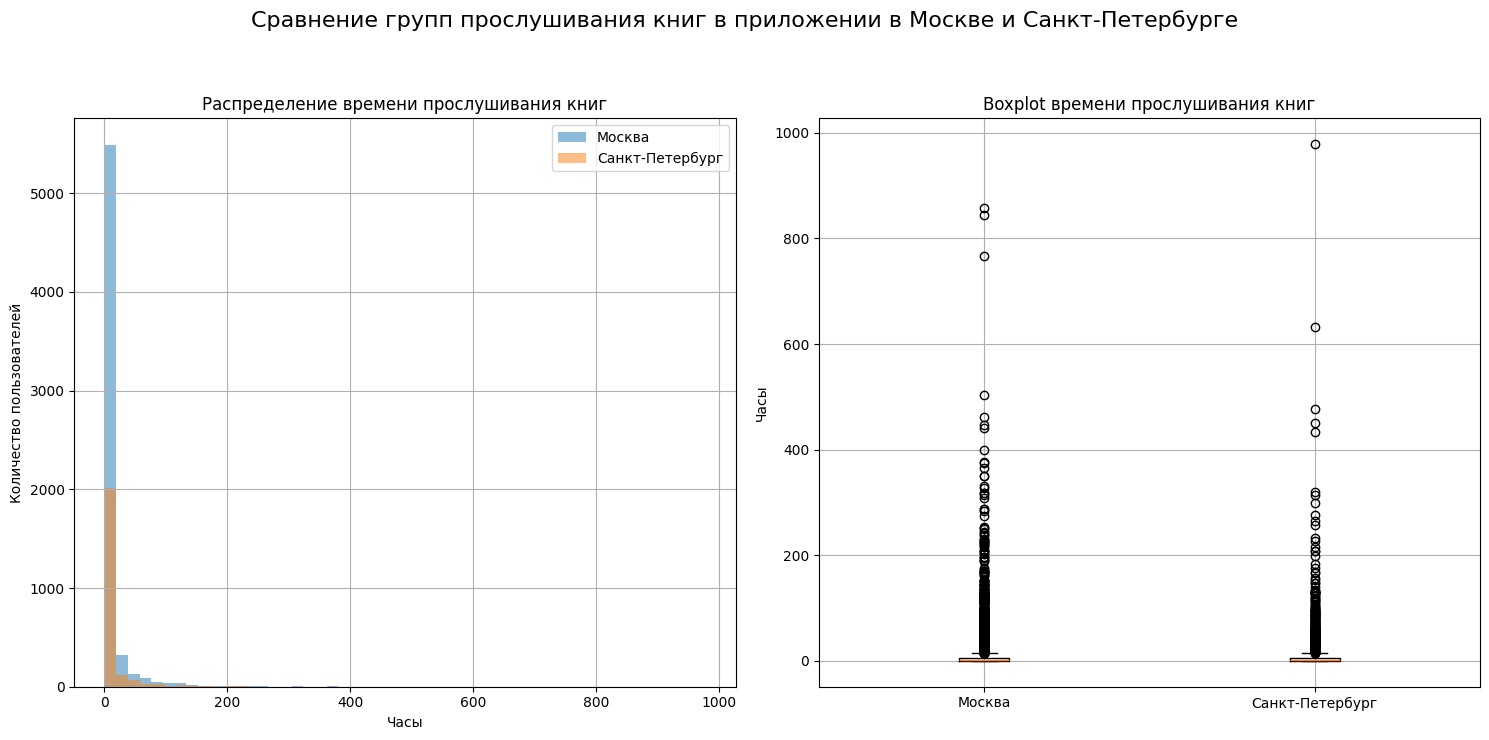

In [9]:
# Данные по городам
moscow_data = yandex_knigi_data[yandex_knigi_data['city'] == 'Москва']['hours']
spb_data = yandex_knigi_data[yandex_knigi_data['city'] == 'Санкт-Петербург']['hours']

# Создаем фигуру и оси с нужным размером
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(15, 7))

# Строим гистограмму
ax_hist.hist(moscow_data, bins=45, alpha=0.5, color='#1f77b4')
ax_hist.hist(spb_data, bins=50, alpha=0.5, color='#ff7f0e')

# Устанавливаем подписи для заголовка, осей x и y
ax_hist.set_title('Распределение времени прослушивания книг')
ax_hist.set_xlabel('Часы')
ax_hist.set_ylabel('Количество пользователей')

ax_hist.legend(['Москва', 'Санкт-Петербург'], loc='upper right')
ax_hist.grid(True)

# Строим boxplot
box_data = [moscow_data, spb_data]
box = ax_box.boxplot(box_data)

# Устанавливаем подписи для заголовка, осей
ax_box.set_title('Boxplot времени прослушивания книг')
ax_box.set_ylabel('Часы')
ax_box.set_xticklabels(['Москва', 'Санкт-Петербург'])

ax_box.grid(True)

# Общий заголовок
fig.suptitle('Сравнение групп прослушивания книг в приложении в Москве и Санкт-Петербурге', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Размер групп существенно различается: московская выборка почти в 3 раза больше
- Средние значения групп близки: разница около 0.38 часа (23 минуты) в пользу Санкт-Петербурга
- Медианы практически равны (0.9 ч) и значительно ниже средних значений, что указывает на сильную правостороннюю ассиметрюю: основная масса пользователей проводит в приложении менее часа, а высокие средние обусловлены небольшим числом очень активных пользователей приложения (до 978 часов прослушивания книг)
- Высокие стандартные отклонения (36-40 ч) подтверждают наличие выбросов и неоднородность распределения.

**Заключение:**
Проведённый анализ не подтверждает гипотезу о том, что пользователи из Санкт-Петербурга проводят в приложении Яндекс Книг больше времени, чем москвичи. Для бизнеса это означает, что нет оснований выделять Санкт-Петербург как регион с повышенной активностью, маркетинговые стратегии могут быть едиными для обоих городов.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Для сравнения средних двух независимых выборок стандартным инструментом является t-тест Уэлча (он не требует равенства дисперсий). В нашем случае следует сравнивать среднее время, которые проводят пользователи за чтением и прослушиванием книг, именно поэтому для вышеуказанной гипотезы случае следует использовать t-тест Уэлча как основной.

In [10]:
# Формируем выборки для теста
spb_hours = yandex_knigi_data[yandex_knigi_data['city'] == 'Санкт-Петербург']['hours']
msk_hours = yandex_knigi_data[yandex_knigi_data['city'] == 'Москва']['hours']

# Уровень статистической значимости
alpha = 0.05

# Односторонний t-тест Уэлча (альтернатива: среднее в СПб больше)
stat, p_value = ttest_ind(
    spb_hours,
    msk_hours,
    equal_var=False,
    alternative='greater'
)

print(f"t-статистика: {stat:.4f}")
print(f"Одностороннее p-value: {p_value:.4f}")

# Интерпретация
if p_value < alpha:
    print("Отвергаем H₀: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо")
else:
    print("Не отвергаем H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.")

t-статистика: 0.4028
Одностороннее p-value: 0.3436
Не отвергаем H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



**Аналитическая записка по результатам проверки гипотезы о времени активности пользователей Яндекс Книг:**
1. **Выбранный статистический критерий и уровень значимости**  
   Для проверки гипотезы о том, что пользователи из Санкт-Петербурга проводят в приложении в среднем больше времени, чем пользователи из Москвы, был применён односторонний t-тест Уэлча (для двух независимых выборок с неравными дисперсиями). Выбор обусловлен следующими особенностями данных:
    - Целевая метрика - среднее время (hours), что требует параметрического критерия для средних.
    - Тест Уэлча не предполагает равенства дисперсий, что важно, поскольку стандартные отклонения в группах различаются (36.85 и 39.83).
    - Большие размеры выборок (Москва - 6234, Санкт-Петербург - 2306) делают тест устойчивым к отклонениям от нормальности.
    - Уровень статистической значимости принят стандартным: alpha = 0.05.
3. **Результаты теста**
    - **t-статистика:** 0.4028
    - **p-value (одностороннее):** 0.3436
4. **Интерпретация результатов**
    - Полученное p-value (0.3436) значительно превышает выбранный уровень значимости 0.05. Нулевая гипотеза не отвергается. Это означает, что нет статистически значимых доказательств того, что среднее время активности пользователей из Санкт-Петербурга выше, чем у пользователей из Москвы.
5. **Возможные причины полученного результата**
    - **Схожесть пользовательской аудитории.** Различия в поведении аудитории из Москвы и Санкт-Петербурга могут быть минимальными.
    - **Влияние выбросов.** Наличие небольшого числа пользователей с огромным временем (до 978 часов) создаёт сильный разброс и увеличивает стандартное отклонение, что затрудняет обнаружение статистически значимых различий, даже если бы они существовали.
    - **Разный размер групп.** Выборка пользователей из Санкт-Петербурга (2306 человек) почти в 3 раза меньше московской (6234 человека). При такой диспропорции мощность теста может быть недостаточной для выявления небольшого эффекта.